# Thesis BaseLine

This baseline is meant to be a recreation of the Text-to-SQL solution I help develop during my time at Samsung. When I left the pipeline had an LLM Planning call, an agent that could generate and run queries, an SQL results evaluator, and am LLM response call. The goal of the Samsung product was to generate a response for the user question, the goal of this thesis is to generate accurate SQL, therefore the response agent will be removed from this baseline. The planning agent is still in question, intial baseline build will not include it. While the table schema was to the system prompt, this baseline will instead automatically make a tool call prior to the generation agent so the table schema will show up in the coversation history rather than the system prompt. The generation agent will be instructed to generate a query but after the query is generated is where there are some possibilities for different approaches:
1. The generator runs the query, edits it on error response, or passes the query as output on success.
2. An evaluator is placed in front of the execution tool call to examine the query prior to execution.
3. An evaluator is place after the tool call to catch error messages and evaluate if the response from the query accruately answers the user quesion. (asking if it answers the user question would not be representative of the original Samsung pipeline)

I believe option 1 is likely the best and the most represenative of the Samsung pipeline.

In [86]:
#LangSmith Setup
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print(os.getenv("LANGSMITH_API_KEY"))
print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_ENDPOINT"))
print(os.getenv("LANGSMITH_PROJECT"))
print(os.getenv("OPENAI_API_KEY"))

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
true
https://api.smith.langchain.com
ttsqlBaseLine
None


In [87]:
from langchain_ollama import ChatOllama

#LLM
llm = ChatOllama(
    model="qwen3:1.7b", #  phi3, gemma3:12b, gpt-oss:20b, qwen3:1.7b,
    temperature=0,
    base_url="http://localhost:11434/"
)

from langchain_community.utilities import SQLDatabase
from pathlib import Path

def load_databases(base_path):
    """Load .sqlite databases"""
    databases = {}
    for db_file in Path(base_path).rglob("*.sqlite"):
        db_name = db_file.parent.name
        uri = f"sqlite:///{db_file.resolve()}"
        databases[db_name] = SQLDatabase.from_uri(uri)
    return databases


databases = load_databases(r"C:/Users/peter/Documents/SJSU/Thesis/code/mini_dev/minidev_0703/minidev/MINIDEV/dev_databases/")

In [88]:
from langchain.tools import tool, ToolRuntime
import ast
from textwrap import dedent
from typing_extensions import TypedDict
from langgraph.graph import MessagesState

# Define tools

# a tool to be executed manual to retrieve all database tables
@tool
def get_schema(db_name: str) -> str:
    """Retrieves all available tables in database by running "SHOW TABLES;" statement.
    
    Args:
        No Args
    """
    query = f"SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';"

    db = databases[db_name]
    tables = db.run(query)
    
    tables_list = ast.literal_eval(tables)

    database_info = []

    for table_tuple in tables_list:
        table_name = table_tuple[0]
        
        # Get schema
        schema_query = f"PRAGMA table_info({table_name});"
        schema = db.run(schema_query)
        
        # Get first 3 rows
        sample_query = f"SELECT * FROM {table_name} LIMIT 3;"
        sample_data = db.run(sample_query)
        
        # Format for LLM
        table_info = dedent(f"""
            Table: {table_name}
            Schema: {schema}
            Sample Data (first 3 rows): {sample_data}
            ---
            """)
        database_info.append(table_info)

    # Combine all table information
    formatted_output = "\n".join(database_info)

    return formatted_output

@tool
def execute_query(query: str) -> str:
    """Execute a SQL SELECT query and return the results.
    
    Only SELECT statements are permitted for data safety.
    Returns formatted results or error messages.
    
    Args:
        query: The SQL SELECT query to execute
    """
    # Strip whitespace and check query type
    query_stripped = query.strip()
    query_upper = query_stripped.upper()
    
    # Block non-SELECT queries
    dangerous_keywords = ['INSERT', 'UPDATE', 'DELETE', 'DROP', 'CREATE', 'ALTER', 'TRUNCATE']
    if any(query_upper.startswith(keyword) for keyword in dangerous_keywords):
        return f"Error: Only SELECT queries are allowed. Detected forbidden operation."
    
    if not query_upper.startswith('SELECT'):
        return "Error: Query must start with SELECT."
    
    try:
        result = db.run(query_stripped)
        if not result or result.strip() == '':
            return "Query executed successfully but returned no results."
        return result
    except Exception as e:
        return f"Error executing query: {str(e)}\nQuery was: {query_stripped}"
    
tools = [execute_query]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langgraph.graph import START, END
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

from typing_extensions import Literal

class State(MessagesState):
    db_name: str

def user_node(state: State):
    """Represents the user"""

    return {"messages":state["messages"]}

def get_schema_node(state: State):
    """Performs the tool call"""

    observation = get_schema.invoke(state["db_name"])
    result = ToolMessage(content=observation, tool_call_id="0000001")
    return {"messages":result}


dialect = 'SQLite'

# Nodes
def llm_SQLGenerator_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    system_message_content = """You are a helpful SQL generation agent designed to generate {dialect} to handle the user task.""".format(dialect=dialect)

    return {
        "messages":[
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content=system_message_content
                    )
                ]
                + state["messages"]
            )
        ]
    }


def execution_tool_node(state: dict):
    """Performs the SQL statement execution tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages":result}

def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop base upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop
    return END

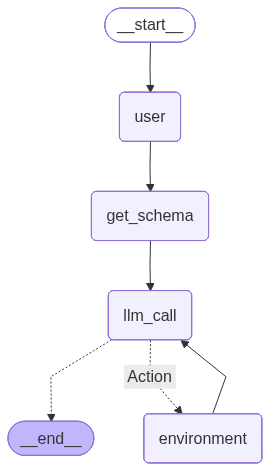

In [ ]:
from langgraph.graph import StateGraph

from IPython.display import Image, display

# Build workflow
agent_builder = StateGraph(State)

# Add nodes
agent_builder.add_node("user", user_node)
agent_builder.add_node("get_schema", get_schema_node)
agent_builder.add_node("llm_sqlGen_call", llm_SQLGenerator_call)
agent_builder.add_node("environment", execution_tool_node)


# Add edges to connect nodes
agent_builder.add_edge(START, "user")
agent_builder.add_edge("user", "get_schema")
agent_builder.add_edge("get_schema", "llm_sqlGen_call")
agent_builder.add_conditional_edges(
    "llm_sqlGen_call",
    should_continue,
    {
        # Name returned by should_continue : Name of next node to visit
        "Action" : "environment",
        END: END,
    }
)
agent_builder.add_edge("environment", "llm_sqlGen_call")

agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [91]:
#db_arg_for_agent = SQLDatabase.from_uri(r"sqlite:///C:\Users\peter\Documents\SJSU\Thesis\code\mini_dev\minidev_0703\minidev\MINIDEV\dev_databases\debit_card_specializing\debit_card_specializing.sqlite")
db_name = 'california_schools'
messages = [HumanMessage(content="Get 5 examples products in the database.")]
messages = agent.invoke({"messages": messages, 'db_name': db_name})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Get 5 examples products in the database.
================================= Tool Message =================================


Table: frpm
Schema: [(0, 'CDSCode', 'TEXT', 1, None, 1), (1, 'Academic Year', 'TEXT', 0, None, 0), (2, 'County Code', 'TEXT', 0, None, 0), (3, 'District Code', 'INTEGER', 0, None, 0), (4, 'School Code', 'TEXT', 0, None, 0), (5, 'County Name', 'TEXT', 0, None, 0), (6, 'District Name', 'TEXT', 0, None, 0), (7, 'School Name', 'TEXT', 0, None, 0), (8, 'District Type', 'TEXT', 0, None, 0), (9, 'School Type', 'TEXT', 0, None, 0), (10, 'Educational Option Type', 'TEXT', 0, None, 0), (11, 'NSLP Provision Status', 'TEXT', 0, None, 0), (12, 'Charter School (Y/N)', 'INTEGER', 0, None, 0), (13, 'Charter School Number', 'TEXT', 0, None, 0), (14, 'Charter Funding Type', 'TEXT', 0, None, 0), (15, 'IRC', 'INTEGER', 0, None, 0), (16, 'Low Grade', 'TEXT', 0, None, 0), (17, 'High Grade', 'TEXT', 0, Non